<a href="https://colab.research.google.com/github/samibennane/stm32-embedded-ai-predictive-maintenance/blob/mlpmodel/TP_IA_EMBARQUEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import urllib
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import classification_report
print(tf.__version__)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

2.19.0


**QUESTION:** Load dataset and display some lines of the csv file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_embedded_ai/ai4i2020.csv")
df.head()


Mounted at /content/drive


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

Machine failure
0    9661
1     339
Name: count, dtype: int64


Text(0.5, 1.0, 'Failures distribution')

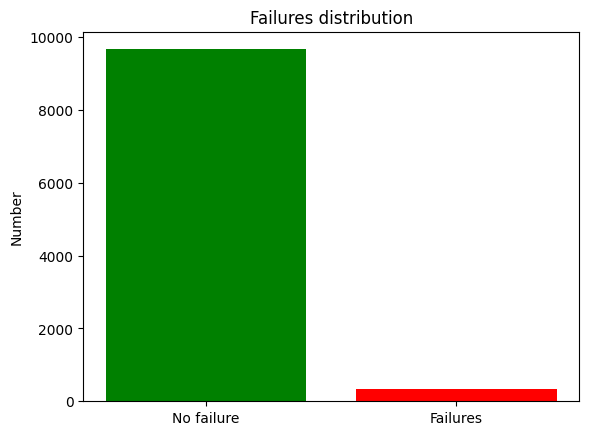

In [ ]:
print(df['Machine failure'].value_counts())
counts = df['Machine failure'].value_counts()
plt.bar(counts.index,counts.values,color = ['green','red'])
plt.xticks([0,1],['No failure','Failures'])
plt.ylabel('Number')
plt.title('Failures distribution')

**ANALYSIS QUESTION:** What do you observe?




We observe that an approximate amount of 3.5% of failures on the total (339/9661)

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

The significant class imbalance (96.5% no failure vs 3.5% failures) will bias the model toward always predicting "No failure", achieving high accuracy while being useless at detecting actual failures. Standard accuracy becomes a misleading metric, maybe F1-score, recall and precision are more appropriate. Solutions could include undersampling, oversampling, or applying class weights during training.

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

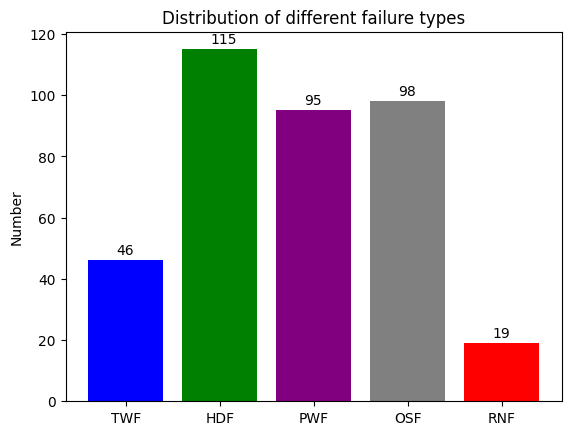

In [ ]:

def distribution_failure_types(df) :
  twf = df['TWF'].sum() #to get the number of occurences for a failure, we simply sum the number of 1
  hdf = df['HDF'].sum()
  pwf = df['PWF'].sum()
  osf = df['OSF'].sum()
  rnf = df['RNF'].sum()

  height = [twf, hdf, pwf, osf, rnf]
  x = [0,1,2,3,4]

  plt.bar(x,height, color = ['blue','green','purple','gray','red'])

  plt.xticks([0,1,2,3,4], ['TWF','HDF','PWF','OSF','RNF'])
  plt.ylabel('Number')
  plt.title('Distribution of different failure types')
  for i,h in zip(x,height) :
    plt.text(i-0.1,h+2,h)

distribution_failure_types(df)


**ANALYSIS QUESTION:** What do you observe?

We observe that HDF is the most common failure type with about 115 occurrences, followed by OSF with about 98 and PWF with about 95. TWF has about 47 occurrences while RNF is the rarest with only about 20 cases.

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

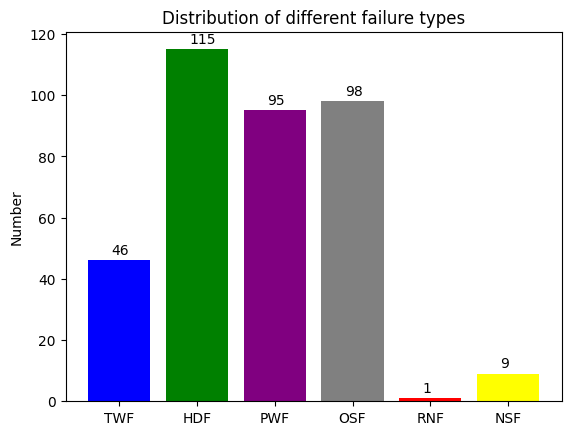

In [ ]:
filtered_df = df[df['Machine failure']==1].copy()

condition = ( (filtered_df['TWF'] == 0) &
             (filtered_df['HDF'] == 0) &
             (filtered_df['PWF'] == 0) &
             (filtered_df['OSF'] == 0) &
             (filtered_df['RNF'] == 0) ) #condition is a panda Series with True and False values

filtered_df['No Specific Failure'] = condition.astype(int) #transform True and False into 0 and 1 to be summed

twf = filtered_df['TWF'].sum()
hdf = filtered_df['HDF'].sum()
pwf = filtered_df['PWF'].sum()
osf = filtered_df['OSF'].sum()
rnf = filtered_df['RNF'].sum()
nsf = filtered_df['No Specific Failure'].sum()

height = [twf, hdf, pwf, osf, rnf,nsf]
x = [0,1,2,3,4,5]
failure_type = ['TWF','HDF','PWF','OSF','RNF','NSF'] #'NSF' =  'No Specific Failure'

plt.bar(x,height, color = ['blue','green','purple','gray','red','yellow'])

plt.xticks(x, failure_type)
plt.ylabel('Number')
plt.title('Distribution of different failure types')

for i,h in zip(x,height) :
  plt.text(i-0.1,h+2,h)




**ANALYSIS QUESTION:** What do you observe comapred to the previous question ? What can you conclude?

Compared to the previous chart which showed all RNF cases, we observe that RNF drops drastically (from 20 to 1) when filtering only machines with Machine failure == 1. This suggests inconsistencies in the dataset : some RNF entries are recorded without a corresponding machine failure, which is logically contradictory. Additionally, 9 machines experienced a failure but had no specific failure type recorded (NSF), likely due to data entry errors or untracked failure modes. These data quality issues could introduce noise during model training and may require data cleaning beforehand.


**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [ ]:
df.dtypes

,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

The inputs will be the physical measurements: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], and Type (after encoding, since it's currently a string/object). Columns like UDI and Product ID are just identifiers and should be excluded.
The outputs will be Machine failure (binary prediction: will it fail?) and the failure types TWF, HDF, PWF, OSF, RNF (what kind of failure?).
As observed previously, RNF shows inconsistencies (failures recorded without Machine failure == 1), so it may need to be excluded. The strong class imbalance (3.5% failures) also means the model must be evaluated beyond simple accuracy.


## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [ ]:
new_df = df.copy()

# creation of a multi-class label without RNF that will be the output

new_df['Failure_type'] = 0
new_df.loc[new_df['TWF'] == 1, 'Failure_type'] = 1
new_df.loc[new_df['HDF'] == 1, 'Failure_type'] = 2
new_df.loc[new_df['PWF'] == 1, 'Failure_type'] = 3
new_df.loc[new_df['OSF'] == 1, 'Failure_type'] = 4
new_df.loc[new_df['RNF'] == 1, 'Failure_type'] = 5


new_df = new_df[new_df['Failure_type'] != 5] #we delete the RNF failures, since its datas are not reliable
new_df = new_df[~((new_df['Failure_type'] == 0) & (new_df['Machine failure'] == 1))] #we delete lines that assert that a machine has a failure but no specific failure is indicated

new_df['Failure_type'] = new_df['Failure_type'].astype(int) #safety to make sure objects are int

print("Distribution sans RNF :", Counter(new_df['Failure_type']))


X = new_df[
    ['Air temperature [K]',
     'Process temperature [K]',
     'Rotational speed [rpm]',
     'Torque [Nm]',
     'Tool wear [min]',
     'Type']
] #inputs

X = pd.get_dummies(X, columns=['Type']) #encoding of the input 'Type' since it is a string

y = new_df['Failure_type'] #output


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

print("Train distribution :", Counter(y_train))
print("Test distribution :", Counter(y_test))

Distribution sans RNF : Counter({0: 9643, 2: 106, 4: 98, 3: 83, 1: 42})
Train distribution : Counter({0: 7719, 2: 90, 4: 72, 3: 60, 1: 36})
Test distribution : Counter({0: 1924, 4: 26, 3: 23, 2: 16, 1: 6})


**QUESTION** Code below the model architecture

In [ ]:
# input layer
inputs = tf.keras.Input(shape=(8,))

# hidden layers, bact normalization is used to fight overfitting
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

outputs = tf.keras.layers.Dense(5, activation='softmax')(x)


**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

Model: "my_mlp_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,133 (16.14 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1350 - loss: 2.2607 - val_accuracy: 0.0080 - val_loss: 5.4244
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2494 - loss: 1.8579 - val_accuracy: 0.0070 - val_loss: 2.7514
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3330 - loss: 1.6725 - val_accuracy: 0.0085 - val_loss: 2.1665
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3763 - loss: 1.5842 - val_accuracy: 0.0471 - val_loss: 1.7834
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4679 - loss: 1.5109 - val_accuracy: 0.1238 - val_loss: 1.5901
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5276 - loss: 1.4662 - val_accuracy: 0.3068 - val_loss: 1.5440
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6042 - loss: 1.4080 - val_accuracy: 0.3970 - val_loss: 1.5323
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6621 - loss: 1.3720 - val_accuracy: 0.3930 - val_loss:

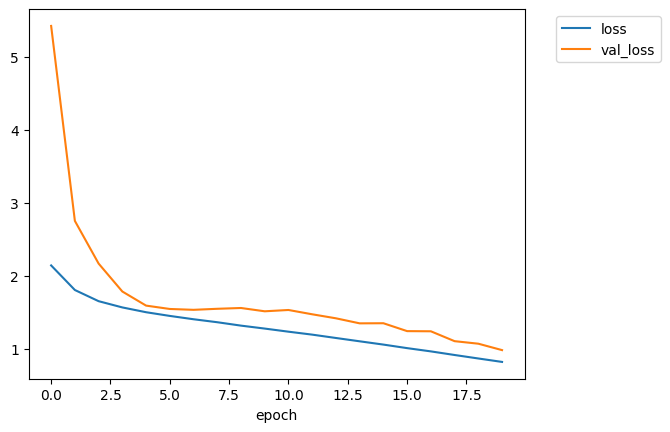

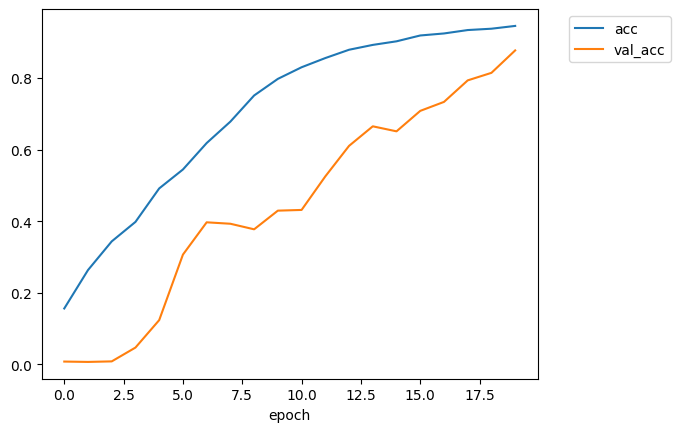

In [ ]:
# model
my_mlp_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="my_mlp_model"
)

# TRAINING


# summary
my_mlp_model.summary()

# compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

my_mlp_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nb_epochs = 20
batch_size = 150

# training
training_history = my_mlp_model.fit(
    X_train,
    y_train,
    epochs=nb_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test)
)

# evaluation
loss_train, acc_train = my_mlp_model.evaluate(
    X_train,
    y_train,
    batch_size=batch_size
)

loss_test, acc_test = my_mlp_model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size
)

print("Performance on TRAIN set, ACCURACY=", acc_train)
print("Performance on TEST set, ACCURACY=", acc_test)

def display_training_curves(training_history):
  # display loss
  plt.plot(training_history.history['loss'],label='loss')
  plt.plot(training_history.history['val_loss'], label='val_loss')
  plt.xlabel("epoch")
  plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
  plt.show()
  #display accuracy
  plt.plot(training_history.history['accuracy'],label='acc')
  plt.plot(training_history.history['val_accuracy'], label='val_acc')
  plt.xlabel("epoch")
  plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
  plt.show()

display_training_curves(training_history)

**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Check sizes: 1995 1995


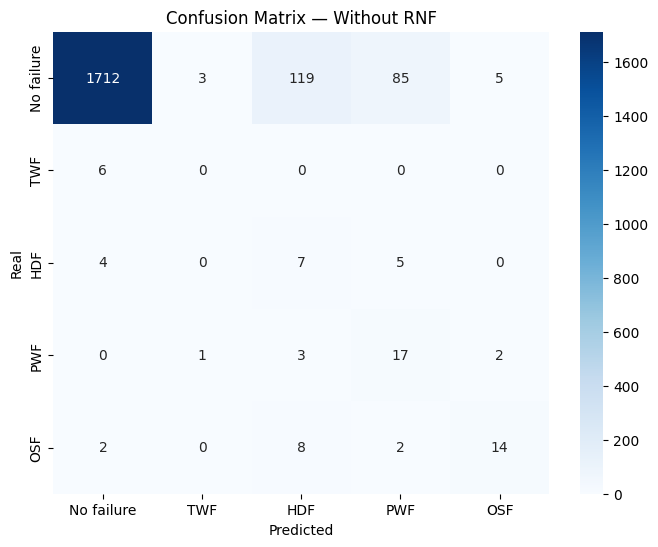


Classification Report (No RNF):

              precision    recall  f1-score   support

  No failure       0.99      0.89      0.94      1924
         TWF       0.00      0.00      0.00         6
         HDF       0.05      0.44      0.09        16
         PWF       0.16      0.74      0.26        23
         OSF       0.67      0.54      0.60        26

    accuracy                           0.88      1995
   macro avg       0.37      0.52      0.38      1995
weighted avg       0.97      0.88      0.92      1995



In [ ]:
labels = ['No failure', 'TWF', 'HDF', 'PWF', 'OSF']

# predictions
Y_pred = my_mlp_model.predict(X_test)
y_pred_class = np.argmax(Y_pred, axis=1)

# true labels
y_true_class = y_test.values

print("Check sizes:", len(y_true_class), len(y_pred_class))

# CONFUSION MATRIX
cm = confusion_matrix(
    y_true_class,
    y_pred_class,
    labels=range(5)
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix — Without RNF")
plt.show()

# CLASSIFICATION REPORT
print("\nClassification Report (No RNF):\n")
print(classification_report(
    y_true_class,
    y_pred_class,
    target_names=labels
))

**ANALYSIS QUESTION** What do you observe? What can you conclude?

The confusion matrix shows that without rebalancing, the model almost systematically predicts
"No failure", 1712 out of 1924 true "No failure" are correctly identified, but at the cost
of completely ignoring minority classes: TWF scores 0 correct predictions out of 6, HDF only
7 out of 16, and OSF 14 out of 20. The model has essentially learned to predict the majority
class by default. The few correct predictions on HDF, PWF and OSF are marginal and do not
reflect any real discriminative capability. This is a direct consequence of the severe class
imbalance (~97% "No failure"), the model is rewarded for ignoring failures entirely.
.

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [ ]:
df_no_rnf = df.copy()

# création label multiclass
df_no_rnf['Failure_type'] = 0
df_no_rnf.loc[df_no_rnf['TWF'] == 1, 'Failure_type'] = 1
df_no_rnf.loc[df_no_rnf['HDF'] == 1, 'Failure_type'] = 2
df_no_rnf.loc[df_no_rnf['PWF'] == 1, 'Failure_type'] = 3
df_no_rnf.loc[df_no_rnf['OSF'] == 1, 'Failure_type'] = 4
df_no_rnf.loc[df_no_rnf['RNF'] == 1, 'Failure_type'] = 5


df_no_rnf = df_no_rnf[df_no_rnf['Failure_type'] != 5]

df_no_rnf['Failure_type'] = df_no_rnf['Failure_type'].astype(int)

print("Distribution sans RNF :", Counter(df_no_rnf['Failure_type']))


X2 = df_no_rnf[
    ['Air temperature [K]',
     'Process temperature [K]',
     'Rotational speed [rpm]',
     'Torque [Nm]',
     'Tool wear [min]',
     'Type']
]

X2 = pd.get_dummies(X2, columns=['Type'])

y2 = df_no_rnf['Failure_type']


X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Train distribution :", Counter(y_train2))
print("Test distribution :", Counter(y_test2))

# Normalisation des features via StandardScaler
# fit_transform sur le train : calcule moyenne et écart-type, puis normalise
# transform sur le test : applique les mêmes paramètres (sans recalculer)
# → évite le data leakage : le test ne doit jamais influencer la normalisation

scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)


smote2 = SMOTE(random_state=42)

X_train_smote2, y_train_smote2 = smote2.fit_resample(
    X_train2,
    y_train2
)

print("After SMOTE :", Counter(y_train_smote2))


target_count = 2000

undersample_strategy2 = {
    label: target_count for label in set(y_train_smote2)
}

undersampler2 = RandomUnderSampler(
    sampling_strategy=undersample_strategy2,
    random_state=42
)

X_train_final2, y_train_final2 = undersampler2.fit_resample(
    X_train_smote2,
    y_train_smote2
)

print("Final distribution :", Counter(y_train_final2))
print("Final shape :", X_train_final2.shape)

Distribution sans RNF : Counter({0: 9652, 2: 106, 4: 98, 3: 83, 1: 42})
Train distribution : Counter({0: 7721, 2: 85, 4: 78, 3: 66, 1: 34})
Test distribution : Counter({0: 1931, 2: 21, 4: 20, 3: 17, 1: 8})
After SMOTE : Counter({0: 7721, 1: 7721, 4: 7721, 3: 7721, 2: 7721})
Final distribution : Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000})
Final shape : (10000, 8)


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

We combined two rebalancing techniques to address the severe class imbalance (~97% No Failure).

First, SMOTE (Synthetic Minority Oversampling Technique) generates synthetic examples for
minority classes (TWF, HDF, PWF, OSF) by interpolating between real examples and their
k nearest neighbors. This avoids simply duplicating existing examples and instead creates
new plausible data points in the feature space.

However, SMOTE alone leaves the majority class (No Failure) largely dominant. We therefore
applied RandomUnderSampler to bring all classes down to 2000 examples each. The target of
2000 was chosen as a compromise: large enough to preserve diversity in the majority class,
small enough to avoid the minority classes being overwhelmed after SMOTE.

The final distribution is perfectly balanced: {0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000},
with a total shape of (10000, 8) — 10000 training examples across 8 features.

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [ ]:
# input layer
inputs = tf.keras.Input(shape=(8,))

# hidden layers
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

outputs = tf.keras.layers.Dense(5, activation='softmax')(x)


**QUESTION** Code below the algorithms allowing to train model


Model: "my_mlp_model_no_rnf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,133 (16.14 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1627 - loss: 2.2547 - val_accuracy: 0.1262 - val_loss: 1.6360
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4358 - loss: 1.3771 - val_accuracy: 0.1893 - val_loss: 1.5834
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6612 - loss: 0.9546 - val_accuracy: 0.3300 - val_loss: 1.4313
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7656 - loss: 0.7319 - val_accuracy: 0.5018 - val_loss: 1.2201
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8188 - loss: 0.5982 - val_accuracy: 0.5859 - val_loss: 1.0466
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8525 - loss: 0.5174 - val_accuracy: 0.6415 - val_loss: 0.9151
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8783 - loss: 0.4419 - val_accuracy: 0.6790 - val_loss: 0.8238
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8914 - loss: 0.4022 - val_accuracy: 0.7116 - val_lo

Performance on TRAIN set, ACCURACY= 0.9653000235557556
Performance on TEST set, ACCURACY= 0.8512769341468811


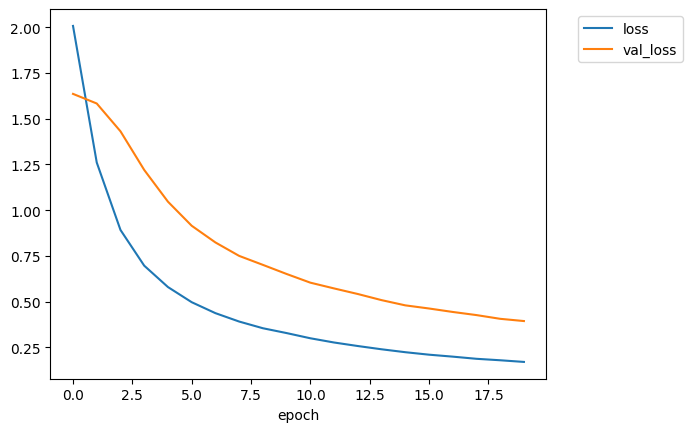

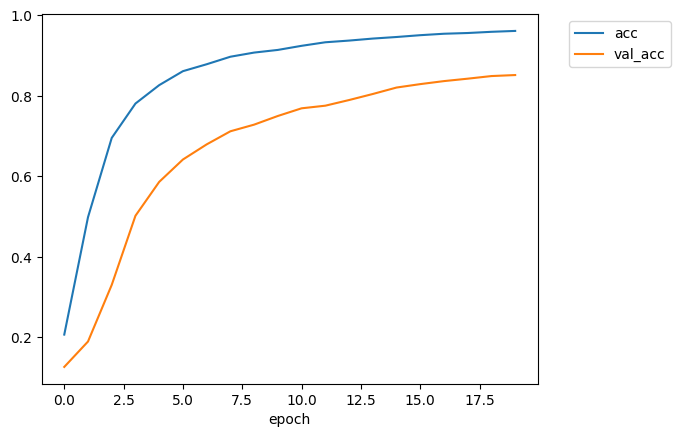

In [ ]:

# model
my_mlp_model_no_rnf = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="my_mlp_model_no_rnf"
)

# ==============================
# TRAINING
# ==============================

# summary
my_mlp_model_no_rnf.summary()

# compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

my_mlp_model_no_rnf.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nb_epochs = 20
batch_size = 150

# training
training_history_no_rnf = my_mlp_model_no_rnf.fit(
    X_train_final2,
    y_train_final2,
    epochs=nb_epochs,
    batch_size=batch_size,
    validation_data=(X_test2, y_test2)
)

# evaluation
loss_train, acc_train = my_mlp_model_no_rnf.evaluate(
    X_train_final2,
    y_train_final2,
    batch_size=batch_size
)

loss_test, acc_test = my_mlp_model_no_rnf.evaluate(
    X_test2,
    y_test2,
    batch_size=batch_size
)

print("Performance on TRAIN set, ACCURACY=", acc_train)
print("Performance on TEST set, ACCURACY=", acc_test)

my_mlp_model_no_rnf.save("machine_failure_model.h5")
np.save("machine_failure_xtest.npy", X_test2)
np.save("machine_failure_ytest.npy", y_test2)

display_training_curves(training_history_no_rnf)

**QUESTION** Plot the confusion matrix and the classification report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Check sizes: 1997 1997


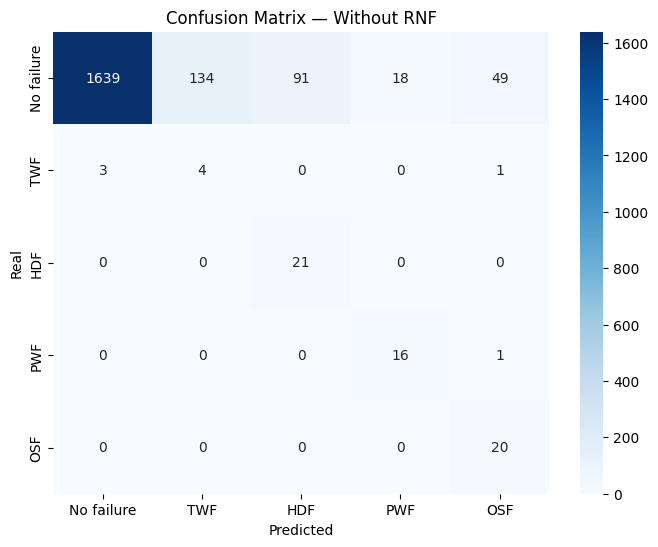


Classification Report (No RNF):

              precision    recall  f1-score   support

  No failure       1.00      0.85      0.92      1931
         TWF       0.03      0.50      0.05         8
         HDF       0.19      1.00      0.32        21
         PWF       0.47      0.94      0.63        17
         OSF       0.28      1.00      0.44        20

    accuracy                           0.85      1997
   macro avg       0.39      0.86      0.47      1997
weighted avg       0.97      0.85      0.90      1997



In [ ]:
labels_no_rnf = ['No failure', 'TWF', 'HDF', 'PWF', 'OSF']

# ===== PREDICTIONS =====
Y_pred_no_rnf = my_mlp_model_no_rnf.predict(X_test2)
y_pred_class_no_rnf = np.argmax(Y_pred_no_rnf, axis=1)

# ===== TRUE LABELS =====
y_true_class_no_rnf = y_test2.values

print("Check sizes:", len(y_true_class_no_rnf), len(y_pred_class_no_rnf))

# ===== CONFUSION MATRIX =====
cm_no_rnf = confusion_matrix(
    y_true_class_no_rnf,
    y_pred_class_no_rnf,
    labels=range(5)
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_no_rnf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_no_rnf,
    yticklabels=labels_no_rnf
)

plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix — Without RNF")
plt.show()

# ===== CLASSIFICATION REPORT =====
print("\nClassification Report (No RNF):\n")
print(classification_report(
    y_true_class_no_rnf,
    y_pred_class_no_rnf,
    target_names=labels_no_rnf
))

**ANALYSIS QUESTION** What do you observe? What can you conclude?

After SMOTE + undersampling, all failure classes improve significantly: HDF goes from 0.09 to 0.32, PWF from 0.26 to 0.63, OSF from 0.60 to 0.44 , and the macro F1 jumps from 0.38 to 0.47. The confusion matrix no longer shows entire rows collapsed into "No Failure".
SMOTE + undersampling demonstrably forces the model to learn failure patterns it was previously ignoring entirely. However, TWF remains at near-zero performance even after rebalancing, with only 8 real examples in the test size set, SMOTE generates almost entirely synthetic samples that do not capture the true underlying distribution of this failure mode. The high-recall/low-precision trade-off observed after rebalancing is industrially acceptable in predictive maintenance, missing a real failure is costlier than a false alarm, but TWF would require significantly more real data to be learnable.

In [ ]:
import os

# Vérifier les fichiers dans le répertoire actuel
os.listdir()

['.config',
 'drive',
 'machine_failure_model.h5',
 'machine_failure_ytest.npy',
 'machine_failure_xtest.npy',
 'sample_data']

In [ ]:
from google.colab import files

# Télécharger les fichiers nécessaires
files.download('machine_failure_model.h5')
files.download('machine_failure_xtest.npy')
files.download('machine_failure_ytest.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>